In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from core.data_handler import DataHandler

In [ ]:
aapl_handler = DataHandler('AAPL', period = '2y', interval='1h')
msft_handler = DataHandler('MSFT', period = '2y', interval='1h')
btc_handler = DataHandler('BTC-USD', period = '2y', interval='1h')

# aapl_handler.df['SMA_200'] = aapl_handler.df['Close'].rolling(window=200).mean()
# msft_handler.df['SMA_200'] = msft_handler.df['Close'].rolling(window=200).mean()
# btc_handler.df['SMA_200'] = btc_handler.df['Close'].rolling(window=200).mean()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [15]:
aapl_handler.df.columns

Index(['Datetime', 'Close', 'High', 'Low', 'Open', 'Volume', 'Date', 'Hour',
       'EODClose', 'LogEODClose', 'PrevEODClose', 'LogPrevEODClose', 'Label',
       'SimpleReturn', 'SMA_20', 'SMA_50', 'RSI', 'Volatility', 'LogClose',
       'LogReturn', 'RangePct', 'CloseOpenPct', 'RetLag1', 'RetLag2',
       'RetLag3', 'RetLag5', 'RetLag10', 'RetLag21', 'RollMeanRet5',
       'RollStdRet5', 'PriceMom5', 'RollMeanRet10', 'RollStdRet10',
       'PriceMom10', 'RollMeanRet21', 'RollStdRet21', 'PriceMom21',
       'RollMeanRet63', 'RollStdRet63', 'PriceMom63', 'EMA12', 'EMA26', 'MACD',
       'MACDSignal', 'RSI14', 'ATR14', 'ATR14Pct', 'DayOfWeek', 'Month',
       'HourSin', 'HourCos', 'DoWSin', 'DoWCos', 'MonthSin', 'MonthCos'],
      dtype='str')

<Axes: xlabel='Datetime', ylabel='Closing Price'>

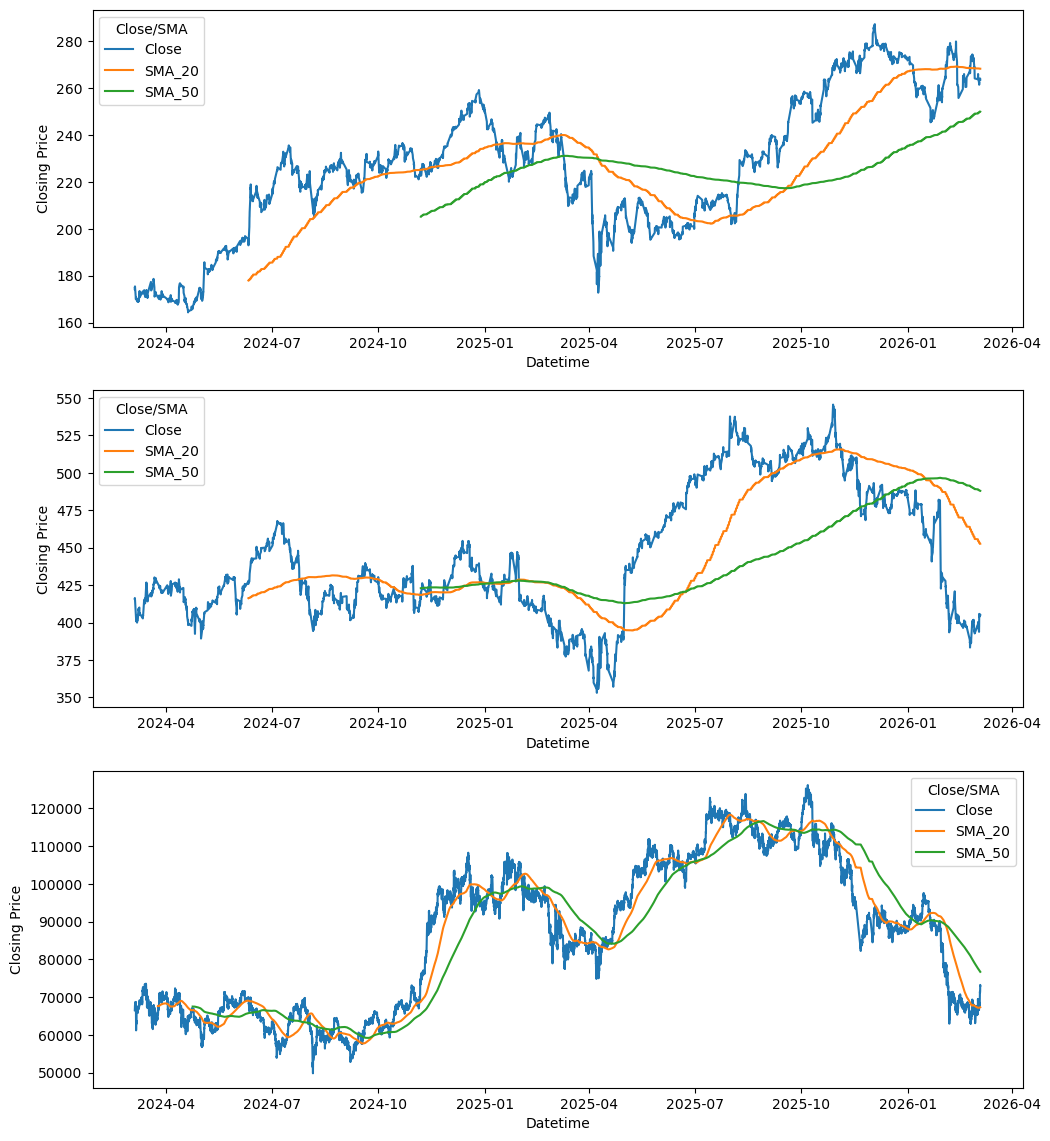

In [12]:
fig, ax = plt.subplots(3, figsize = (12, 14))

sns.lineplot(data=aapl_handler.df.melt(
    id_vars = "Datetime",
    value_vars = ["Close", "SMA_20", "SMA_50"],
    value_name = "Closing Price",
    var_name = "Close/SMA"
), x = "Datetime", y="Closing Price", hue = "Close/SMA", ax=ax[0])

sns.lineplot(data=msft_handler.df.melt(
    id_vars = "Datetime",
    value_vars = ["Close", "SMA_20", "SMA_50"],
    value_name = "Closing Price",
    var_name = "Close/SMA"
), x = "Datetime", y="Closing Price", hue = "Close/SMA", ax=ax[1])

sns.lineplot(data=btc_handler.df.melt(
    id_vars = "Datetime",
    value_vars = ["Close", "SMA_20", "SMA_50"],
    value_name = "Closing Price",
    var_name = "Close/SMA"
), x = "Datetime", y="Closing Price", hue = "Close/SMA", ax=ax[2])


The gold closing value rises, so this will need to be accounted for so the model doesn't always buy. This is done by using Returns, rather than Close, and I could use Close - SMA_20 or SMA_50

<Axes: xlabel='Datetime', ylabel='Price VS SMA'>

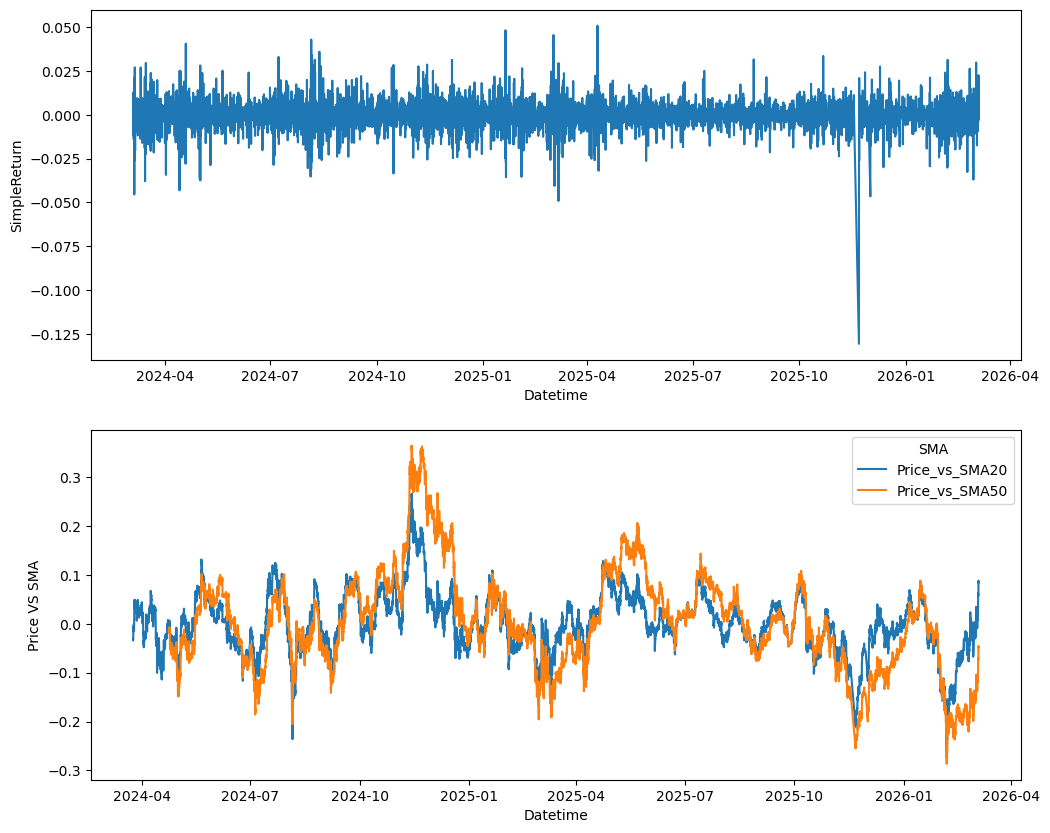

In [13]:
fig, ax = plt.subplots(2, figsize = (12, 10))

sns.lineplot(data=btc_handler.df, x="Datetime", y="SimpleReturn", ax=ax[0])

btc_handler.df['Price_vs_SMA20'] = (btc_handler.df['Close'] - btc_handler.df['SMA_20']) / btc_handler.df['SMA_20']
btc_handler.df['Price_vs_SMA50'] = (btc_handler.df['Close'] - btc_handler.df['SMA_50']) / btc_handler.df['SMA_50']

sns.lineplot(data=btc_handler.df.melt(
    id_vars="Datetime", 
    value_vars=["Price_vs_SMA20", "Price_vs_SMA50"],
    value_name = "Price VS SMA",
    var_name = "SMA"
    ), 
    x="Datetime", y="Price VS SMA", hue ="SMA", ax=ax[1])
#sns.lineplot(data=btc_handler.df, x="Datetime", y="Price_vs_SMA50", ax=ax[1])


Need to do analysis on:
* Threshold to use
* Stop loss and take profit to use

## How to calculate stop loss and take profit
* Calculate decimal up move and down move
* Calculate close move, the decimal if no stop loss or take profit is hit

In [ ]:
def analyse_stop_take(df, thresholds):

    df['UpMove'] = (df['High'] - df['Open']) / df['Open']
    df['DownMove'] = (df['Open'] - df['Low']) / df['Open']
    df['CloseMove'] = (df['Close'] - df['Open']) / df['Open']

    results = []
    for stop in thresholds:
        for take in thresholds:
            if take <= stop:
                continue  # Take profit must be bigger than stop loss

            wins, losses, neutral = 0, 0, 0
            returns = []

            for _, row in df.iterrows():
                up_move   = row['UpMove']
                down_move = row['DownMove']
                close_move = row['CloseMove']

                # Simulate a long trade
                if down_move >= stop:
                    # Stop loss hit
                    returns.append(-stop)
                    losses += 1
                elif up_move >= take:
                    # Take profit hit
                    returns.append(take)
                    wins += 1
                else:
                    # Neither hit — close at EOD
                    returns.append(close_move)
                    neutral += 1

            total_return = pd.Series(returns).add(1).cumprod().iloc[-1] - 1
            results.append({
                'stop_loss'   : stop,
                'take_profit' : take,
                'total_return': total_return,
                'wins'        : wins,
                'losses'      : losses,
                'neutral'     : neutral,
                'risk_reward' : take / stop
            })

    results_df = pd.DataFrame(results).sort_values('total_return', ascending=False)
    #print(results_df.head(10).to_string(index=False))
    return results_df

thresholds = [0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.04, 0.05]

aapl_day_handler = DataHandler('AAPL', period = '4y', interval='1d')
msft_day_handler = DataHandler('MSFT', period = '4y', interval='1d')
btc_day_handler = DataHandler('BTC', period = '4y', interval='1d')

for handler in [aapl_day_handler, msft_day_handler, btc_day_handler]:
    display(analyse_stop_take(handler.df, thresholds).head(10))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,stop_loss,take_profit,total_return,wins,losses,neutral,risk_reward
21,0.020,0.05,1.957888,11,121,871,2.500000
26,0.030,0.05,1.737140,11,40,952,1.666667
20,0.020,0.04,1.716837,18,121,864,2.000000
17,0.015,0.05,1.688732,10,215,778,3.333333
24,0.025,0.05,1.593778,11,77,915,2.000000
27,0.040,0.05,1.552173,11,16,976,1.250000
25,0.030,0.04,1.514079,18,40,945,1.333333
16,0.015,0.04,1.493362,17,215,771,2.666667
6,0.005,0.05,1.486430,8,625,370,10.000000
12,0.010,0.05,1.432359,9,385,609,5.000000


,stop_loss,take_profit,total_return,wins,losses,neutral,risk_reward
21,0.020,0.050,0.327636,5,122,876,2.500000
20,0.020,0.040,0.288464,9,122,872,2.000000
19,0.020,0.030,0.257855,26,122,855,1.500000
18,0.020,0.025,0.257172,50,122,831,1.250000
12,0.010,0.050,0.230304,3,399,601,5.000000
11,0.010,0.040,0.217076,7,399,597,4.000000
10,0.010,0.030,0.185798,21,399,583,3.000000
9,0.010,0.025,0.164089,43,399,561,2.500000
24,0.025,0.050,0.147206,5,75,923,2.000000
17,0.015,0.050,0.134645,4,225,774,3.333333


,stop_loss,take_profit,total_return,wins,losses,neutral,risk_reward
16,0.015,0.040,0.120767,19,147,233,2.666667
17,0.015,0.050,0.114872,8,147,244,3.333333
11,0.010,0.040,0.052126,16,214,169,4.000000
15,0.015,0.030,0.031685,43,147,209,2.000000
12,0.010,0.050,0.024895,6,214,179,5.000000
20,0.020,0.040,0.022445,19,108,272,2.000000
21,0.020,0.050,0.017068,8,108,283,2.500000
10,0.010,0.030,-0.001186,36,214,149,3.000000
19,0.020,0.030,-0.042793,46,108,245,1.500000
14,0.015,0.025,-0.085038,57,147,195,1.666667


Best stop losses and take profits for AAPL and MSFT:  
0.02 and 0.05   
For BTC:  
0.015 and 0.04  

In [ ]:
import matplotlib.pyplot as plt

def gradient_importance(model, X_test, feature_cols):
    model.eval()
    
    X = X_test.clone().requires_grad_(True)
    
    output = model(X).squeeze()
    output.sum().backward()  # Backprop through the whole test set
    
    # Average absolute gradient across samples and timesteps
    # Shape: (samples, timesteps, features) → average to (features,)
    grads = X.grad.abs().mean(dim=(0, 1)).numpy()
    
    # Normalise to percentage
    grads = grads / grads.sum() * 100

    # Plot
    plt.figure(figsize=(10, 5))
    sorted_idx = np.argsort(grads)[::-1]
    plt.bar(
        [feature_cols[i] for i in sorted_idx],
        [grads[i] for i in sorted_idx],
        color='steelblue'
    )
    plt.title("Gradient-Based Feature Importance")
    plt.ylabel("Importance (%)")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    for i in sorted_idx:
        print(f"{feature_cols[i]}: {grads[i]:.2f}%")

    return grads

In [ ]:
from core.data_handler import DataHandler
from core.trading_lstm import TradingLTSM
from sklearn.model_selection import train_test_split
import torch
import numpy as np
import matplotlib.pyplot as plt



# data_handler = DataHandler('AAPL', period="2y")
# df = data_handler.df
# df.dropna(inplace = True)
# columns = df.columns.tolist()
# print(columns)
# remove = ["Datetime", "Date", "Hour", "Label"]
# features = [col for col in columns if col not in remove]
# trading_ltsm = TradingLTSM(hidden_size=64, num_layers=2, seq_len=30, feature_cols=features)
# X, y, scaler = trading_ltsm.prepare_daily_sequences(df)

# X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)

# trading_ltsm.train_model(X_train, y_train, epochs=50)


def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        preds = model(X_test).squeeze()
        pred_labels = (preds > 0.5).float()  # Convert probabilities to 0/1
    
    # Accuracy
    accuracy = (pred_labels == y_test.squeeze()).float().mean().item()
    print(f"Accuracy: {accuracy:.2%}")
    
    return preds, pred_labels


def gradient_importance(model, X_test, feature_cols):
    model.eval()
    
    X = X_test.clone().requires_grad_(True)
    
    output = model(X).squeeze()
    output.sum().backward()  # Backprop through the whole test set
    
    # Average absolute gradient across samples and timesteps
    # Shape: (samples, timesteps, features) → average to (features,)
    grads = X.grad.abs().mean(dim=(0, 1)).numpy()
    
    # Normalise to percentage
    grads = grads / grads.sum() * 100

    # Plot
    plt.figure(figsize=(10, 5))
    sorted_idx = np.argsort(grads)[::-1]
    plt.bar(
        [feature_cols[i] for i in sorted_idx],
        [grads[i] for i in sorted_idx],
        color='steelblue'
    )
    plt.title("Gradient-Based Feature Importance")
    plt.ylabel("Importance (%)")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    for i in sorted_idx:
        print(f"{feature_cols[i]}: {grads[i]:.2f}%")

    return grads


def feature_label_correlation(df, feature_cols, label_col='Label'):
    correlations = {}

    for feature in feature_cols:
        corr = df[feature].corr(df[label_col])
        correlations[feature] = corr

    sorted_corr = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)

    plt.figure(figsize=(10, 5))
    features, corrs = zip(*sorted_corr)
    colors = ['green' if c > 0 else 'red' for c in corrs]
    plt.bar(features, corrs, color=colors)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.title("Feature Correlation With Label")
    plt.ylabel("Correlation")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    for f, c in sorted_corr:
        print(f"{f}: {c:+.4f}")


def find_optimal_threshold(model, X_test, y_test, df):
    model.eval()
    with torch.no_grad():
        preds = model(X_test).squeeze().numpy()
    
    y_true = y_test.squeeze().numpy()
    prices = df['EODClose'].values
    daily_indexed = df.set_index('Date')
    actual_returns = []

    for date in df['Date'].unique():
        row = daily_indexed.loc[date].iloc[0]
        day_return = (row['EODClose'] - row['DayOpen']) / row['DayOpen']
        actual_returns.append(day_return)

    actual_returns = np.array(actual_returns)

    thresholds = np.arange(0.5, 0.95, 0.05)
    results = []

    for threshold in thresholds:
        trades      = 0
        correct     = 0
        strategy    = []

        for i in range(len(preds) - 1):
            day_return = actual_returns[i + 1]

            if preds[i] > threshold:
                trades += 1
                correct += 1 if y_true[i] == 1 else 0
                strategy.append(day_return)

            elif preds[i] < (1 - threshold):
                trades += 1
                correct += 1 if y_true[i] == 0 else 0
                strategy.append(-day_return)

            else:
                strategy.append(0)  # Sitting out

        accuracy      = correct / trades if trades > 0 else 0
        total_return  = pd.Series(strategy).add(1).cumprod().iloc[-1] - 1
        trade_pct     = trades / len(preds) * 100

        results.append({
            'threshold'   : round(threshold, 2),
            'accuracy'    : accuracy,
            'total_return': total_return,
            'trades'      : trades,
            'trade_pct'   : trade_pct
        })

        print(f"Threshold {threshold:.2f} | "
              f"Accuracy: {accuracy:.2%} | "
              f"Return: {total_return:+.2%} | "
              f"Trades: {trades} ({trade_pct:.0f}% of days)")

    results_df = pd.DataFrame(results)
    _plot_threshold_results(results_df)
    return results_df

def _plot_threshold_results(results_df):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(results_df['threshold'], results_df['accuracy'], marker='o', color='blue')
    axes[0].axhline(0.5, color='red', linestyle='--', label='Random baseline')
    axes[0].set_title('Accuracy vs Threshold')
    axes[0].set_xlabel('Threshold')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(results_df['threshold'], results_df['total_return'] * 100, marker='o', color='green')
    axes[1].axhline(0, color='red', linestyle='--')
    axes[1].set_title('Total Return vs Threshold')
    axes[1].set_xlabel('Threshold')
    axes[1].set_ylabel('Return (%)')

    axes[2].bar(results_df['threshold'], results_df['trade_pct'], color='orange', width=0.03)
    axes[2].set_title('% of Days Traded vs Threshold')
    axes[2].set_xlabel('Threshold')
    axes[2].set_ylabel('% Days Traded')

    plt.tight_layout()
    plt.show()



[*********************100%***********************]  1 of 1 completed


['Datetime', 'Close', 'High', 'Low', 'Open', 'Volume', 'Date', 'Hour', 'EODClose', 'LogEODClose', 'PrevEODClose', 'LogPrevEODClose', 'Label', 'SimpleReturn', 'SMA_20', 'SMA_50', 'RSI', 'Volatility', 'LogClose', 'LogReturn', 'RangePct', 'CloseOpenPct', 'RetLag1', 'RetLag2', 'RetLag3', 'RetLag5', 'RetLag10', 'RetLag21', 'RollMeanRet5', 'RollStdRet5', 'PriceMom5', 'RollMeanRet10', 'RollStdRet10', 'PriceMom10', 'RollMeanRet21', 'RollStdRet21', 'PriceMom21', 'RollMeanRet63', 'RollStdRet63', 'PriceMom63', 'EMA12', 'EMA26', 'MACD', 'MACDSignal', 'RSI14', 'ATR14', 'ATR14Pct', 'DayOfWeek', 'Month', 'HourSin', 'HourCos', 'DoWSin', 'DoWCos', 'MonthSin', 'MonthCos']
['Close', 'High', 'Low', 'Open', 'Volume', 'EODClose', 'LogEODClose', 'PrevEODClose', 'LogPrevEODClose', 'SimpleReturn', 'SMA_20', 'SMA_50', 'RSI', 'Volatility', 'LogClose', 'LogReturn', 'RangePct', 'CloseOpenPct', 'RetLag1', 'RetLag2', 'RetLag3', 'RetLag5', 'RetLag10', 'RetLag21', 'RollMeanRet5', 'RollStdRet5', 'PriceMom5', 'RollMeanR

In [ ]:

for ticker in ['AAPL', 'MSFT', 'BTC-USD']:



grads = gradient_importance(trading_ltsm, X_test, features)

In [ ]:
def train_test_model(ticker, remove):
    
    data_handler = DataHandler(ticker, period="4y")
    df = data_handler.df
    df.dropna(inplace = True)
    columns = df.columns.tolist()
    print(columns)

    features = [col for col in columns if col not in remove]
    trading_ltsm = TradingLTSM(hidden_size=64, num_layers=2, seq_len=30, feature_cols=features)
    X, y, scaler = trading_ltsm.prepare_daily_sequences(df)

    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)

    trading_ltsm.train_model(X_train, y_train, epochs=50)

    preds, pred_labels = evaluate_model(trading_ltsm, X_test, y_test)

    gradient_importance(trading_ltsm, X_test, features)

    feature_label_correlation(df, features)

remove = ["Datetime", "Date", "Hour", "Label"]


